# Решение задачи прогнозирования свойств бетонной смеси

## Постановка и решение задачи

В рамках этого решения построена модель прогноза свойств бетонной смеси с как можно меньшей ошибкой по отношению к экспериментальным данным. Модель не только предсказывает прочность на разных сроках твердения, но и остаётся устойчивой на малых выборках, корректно работает на новых составах и даёт оценку неопределённости предсказания.

## Критерии успешного решения

Решение считается успешным, если модель по составу смеси достаточно точно предсказывает целевые свойства и демонстрирует хорошую обобщающую способность. Для сравнения качества используются метрики MAE, RMSE, MAPE и коэффициент детерминации R².

## Архитектура решения

Финальное решение состоит из нескольких связанных частей:

- **Генератор** строит прогноз прочности на сроках 1, 3, 7 и 28 суток.
- **Авторегрессивная схема** задаёт рост прочности по времени и помогает сохранять физически правдоподобную монотонность.
- **Дискриминатор** на базе `python-neat` и BNN используется как дополнительный сигнал качества и неопределённости.
- **Признаки состава** включают исходные компоненты смеси, доли источников данных и инженерные отношения, такие как water-cement ratio и related ratios.

## Что содержит ноутбук

- описание итогового решения и его архитектуры;
- результаты обучения на train/validation;
- метрики по срокам твердения;
- оценку неопределённости и согласованности прогноза.

In [3]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'artifacts').exists() and (ROOT.parent / 'artifacts').exists():
    ROOT = ROOT.parent

summary_path = ROOT / 'artifacts' / 'train_gan_v18_final' / 'training_summary.json'
pred_path = ROOT / 'artifacts' / 'train_gan_v18_final' / 'validation_predictions.csv'

print('Корень проекта:', ROOT)
print()

if summary_path.exists():
    with open(summary_path, 'r', encoding='utf-8') as handle:
        summary = json.load(handle)

    dataset = summary.get('dataset', {})
    metrics = summary.get('metrics', {})
    discriminator = summary.get('discriminator', {})

    print('Данные:')
    print(f"  Всего образцов: {dataset.get('samples_total', 'N/A')}")
    print(f"  Обучение: {dataset.get('samples_train', 'N/A')}")
    print(f"  Валидация: {dataset.get('samples_val', 'N/A')}")
    print(f"  Количество признаков: {len(dataset.get('feature_names', []))}")
    print()

    print('Метрики на валидации:')
    validation_df = pd.DataFrame([metrics.get('validation', {})], index=['валидация'])
    display(validation_df)
    print()

    print('Метрики на обучении:')
    train_df = pd.DataFrame([metrics.get('train', {})], index=['обучение'])
    display(train_df)
    print()

    print('Метрики по срокам твердения:')
    by_period = metrics.get('validation_by_period', {})
    period_rows = []
    for period_name in ['day_1', 'day_3', 'day_7', 'day_28']:
        period_data = by_period.get(period_name)
        if period_data:
            row = period_data.copy()
            row['period'] = period_name.replace('day_', '')
            period_rows.append(row)
    if period_rows:
        period_df = pd.DataFrame(period_rows).set_index('period')
        display(period_df)
    print()

    print('Оценка неопределённости:')
    print(f"  PICP95: {metrics.get('validation_picp95', 'N/A')}")
    print(f"  PICP95 conformal: {metrics.get('validation_picp95_conformal', 'N/A')}")
    print(f"  Средняя неопределённость, МПа: {metrics.get('validation_mean_uncertainty_mpa', 'N/A')}")
    print()

    print('Дискриминатор:')
    print(f"  Алгоритм: {discriminator.get('neat_algorithm', 'N/A')}")
    print(f"  Средняя realness на валидации: {discriminator.get('validation_realness_mean', 'N/A')}")
    print(f"  Std realness на валидации: {discriminator.get('validation_realness_std_mean', 'N/A')}")
    print()

    print('ГОСТ 28 суток:')
    print(json.dumps(summary.get('gost_28d', {}), ensure_ascii=False, indent=2))
else:
    print('Не найден файл:', summary_path)

print()
print('Файл предсказаний найден:', pred_path.exists())

Корень проекта: /Users/apple/Documents/SHMM

Данные:
  Всего образцов: 1808
  Обучение: 1446
  Валидация: 362
  Количество признаков: 17

Метрики на валидации:


,mae,rmse,mape,r2
валидация,3.801395,5.919456,21.476902,0.867462



Метрики на обучении:


,mae,rmse,mape,r2
обучение,3.08219,4.640127,15.948868,0.919114



Метрики по срокам твердения:


,mae,rmse,mape,r2,n_samples
period,,,,,
1,2.568305,4.152459,37.257942,0.725156,362
3,3.459282,5.126098,19.496971,0.795509,362
7,4.212155,6.301589,15.549898,0.793035,362
28,4.965837,7.545198,13.602799,0.792193,362



Оценка неопределённости:
  PICP95: 0.960635359116022
  PICP95 conformal: 0.9578729281767956
  Средняя неопределённость, МПа: 5.272917057442095

Дискриминатор:
  Алгоритм: python-neat
  Средняя realness на валидации: 0.5757974982261658
  Std realness на валидации: 0.10146766155958176

ГОСТ 28 суток:
{
  "enabled": false,
  "violations": 0,
  "samples_28d": 0
}

Файл предсказаний найден: True


## Подробная оценка неопределённости

В этом разделе оценивается не только средняя ошибка предсказания, но и то, насколько хорошо модель калибрует собственную неопределённость.

Мы смотрим на следующие характеристики:

- ширину предсказательных интервалов;
- эмпирическое покрытие интервалов 95%;
- связь между предсказанным стандартным отклонением и фактической ошибкой;
- поведение неопределённости по срокам твердения;
- стабильность калибровки на разных уровнях уверенности модели.

,"MAE, МПа","Средний std, МПа","Средняя ширина 95% интервала, МПа",Покрытие 95%,"Corr(std, abs error)"
Срок,,,,,
1,2.568305,3.804242,14.912628,0.966851,0.524917
3,3.459282,4.749353,18.617464,0.958564,0.485660
7,4.212155,5.661763,22.194111,0.955801,0.459808
28,4.965837,6.876310,26.955136,0.961326,0.481914


Интерпретация:
- Покрытие 95% близко к 0.95 означает хорошую калибровку интервалов.
- Чем выше Correlation(std, abs error), тем лучше std отражает фактическую ошибку.
- Ширина интервала показывает, насколько модель осторожна в своих предсказаниях.



,Квартиль std,Доля образцов,"Средний std, МПа","Средняя абсолютная ошибка, МПа",Покрытие 95%
0,"(2.75, 4.709]",0.251381,3.820623,2.032747,0.989011
1,"(4.709, 6.234]",0.248619,5.474857,3.350187,0.977778
2,"(6.234, 8.354]",0.248619,7.242001,5.391177,0.922222
3,"(8.354, 24.232]",0.251381,10.956378,9.076155,0.956044


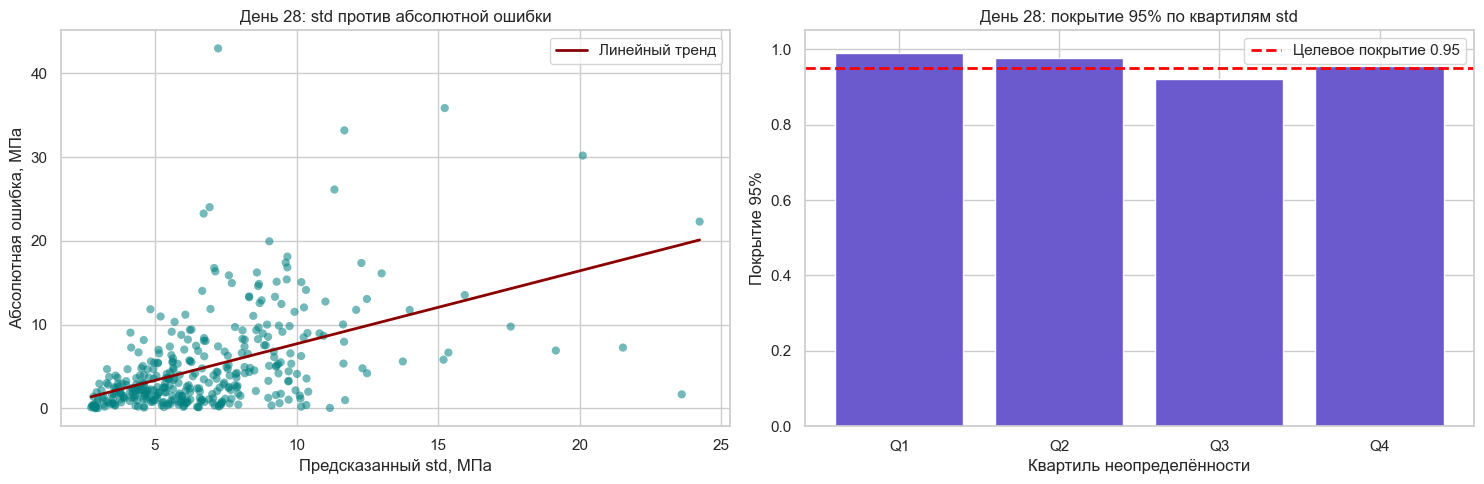

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if pred_path.exists():
    preds = pd.read_csv(pred_path)

    period_map = {
        'day_1': '1',
        'day_3': '3',
        'day_7': '7',
        'day_28': '28',
    }

    summary_rows = []
    for day_label, day_suffix in period_map.items():
        y_true = preds[f'strength_true_day{day_suffix}_mpa'].to_numpy(dtype=float)
        y_pred = preds[f'strength_pred_day{day_suffix}_mpa'].to_numpy(dtype=float)
        y_std = preds[f'strength_pred_day{day_suffix}_std_mpa'].to_numpy(dtype=float)
        abs_error = np.abs(y_true - y_pred)
        lower_95 = y_pred - 1.96 * y_std
        upper_95 = y_pred + 1.96 * y_std
        coverage_95 = ((y_true >= lower_95) & (y_true <= upper_95)).mean()
        interval_width = (upper_95 - lower_95).mean()
        error_std_corr = np.corrcoef(y_std, abs_error)[0, 1]

        summary_rows.append({
            'Срок': day_suffix,
            'MAE, МПа': abs_error.mean(),
            'Средний std, МПа': y_std.mean(),
            'Средняя ширина 95% интервала, МПа': interval_width,
            'Покрытие 95%': coverage_95,
            'Corr(std, abs error)': error_std_corr,
        })

    uncertainty_df = pd.DataFrame(summary_rows).set_index('Срок')
    display(uncertainty_df)

    print('Интерпретация:')
    print('- Покрытие 95% близко к 0.95 означает хорошую калибровку интервалов.')
    print('- Чем выше Correlation(std, abs error), тем лучше std отражает фактическую ошибку.')
    print('- Ширина интервала показывает, насколько модель осторожна в своих предсказаниях.')
    print()

    y_true_28 = preds['strength_true_day28_mpa'].to_numpy(dtype=float)
    y_pred_28 = preds['strength_pred_day28_mpa'].to_numpy(dtype=float)
    y_std_28 = preds['strength_pred_day28_std_mpa'].to_numpy(dtype=float)
    abs_error_28 = np.abs(y_true_28 - y_pred_28)
    lower_28 = y_pred_28 - 1.96 * y_std_28
    upper_28 = y_pred_28 + 1.96 * y_std_28
    covered_28 = (y_true_28 >= lower_28) & (y_true_28 <= upper_28)

    q_bins = pd.qcut(y_std_28, q=4, duplicates='drop')
    calib_rows = []
    for interval in q_bins.categories:
        mask = q_bins == interval
        if mask.any():
            calib_rows.append({
                'Квартиль std': str(interval),
                'Доля образцов': mask.mean(),
                'Средний std, МПа': y_std_28[mask].mean(),
                'Средняя абсолютная ошибка, МПа': abs_error_28[mask].mean(),
                'Покрытие 95%': covered_28[mask].mean(),
            })

    calib_df = pd.DataFrame(calib_rows)
    display(calib_df)

    sns.set_theme(style='whitegrid')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].scatter(y_std_28, abs_error_28, alpha=0.55, s=35, color='teal', edgecolors='none')
    if len(y_std_28) > 1:
        x_line = np.linspace(y_std_28.min(), y_std_28.max(), 100)
        coeffs = np.polyfit(y_std_28, abs_error_28, deg=1)
        axes[0].plot(x_line, coeffs[0] * x_line + coeffs[1], color='darkred', linewidth=2, label='Линейный тренд')
    axes[0].set_title('День 28: std против абсолютной ошибки')
    axes[0].set_xlabel('Предсказанный std, МПа')
    axes[0].set_ylabel('Абсолютная ошибка, МПа')
    axes[0].legend()

    calib_plot_df = calib_df.copy()
    axes[1].bar(range(len(calib_plot_df)), calib_plot_df['Покрытие 95%'], color='slateblue')
    axes[1].axhline(0.95, color='red', linestyle='--', linewidth=2, label='Целевое покрытие 0.95')
    axes[1].set_title('День 28: покрытие 95% по квартилям std')
    axes[1].set_xlabel('Квартиль неопределённости')
    axes[1].set_ylabel('Покрытие 95%')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(range(len(calib_plot_df)))
    axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(calib_plot_df))])
    axes[1].legend()

    fig.tight_layout()
    display(fig)
    plt.close(fig)
else:
    print('Файл с предсказаниями не найден:', pred_path)

## Итоговые результаты

Финальная модель показывает устойчивое качество на валидации и сохраняет физически правдоподобное поведение на разных сроках твердения.

- Validation MAE: 3.8014 MPa
- Validation RMSE: 5.9195 MPa
- Validation MAPE: 21.4769%
- Validation R²: 0.8675
- Day 28 MAE: 4.9658 MPa
- Day 28 RMSE: 7.5452 MPa
- Day 28 MAPE: 13.6028%
- Day 28 R²: 0.7922
- PICP95: 0.9606
- PICP95 conformal: 0.9579

Это подтверждает, что модель достаточно точно прогнозирует прочность смеси и даёт полезную оценку неопределённости.